<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/18_binning_and_binarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

In [68]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/train.csv", usecols=["Age","Fare","Survived"])

In [69]:
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [70]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [71]:
df.dropna(inplace=True)

In [72]:
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [73]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [74]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [75]:
bins_age_fare=KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile")

In [76]:
column_trasfer=ColumnTransformer([
    ("trf1", bins_age,["Age","Fare"])

], remainder="passthrough")

In [77]:
X_train_trf=column_trasfer.fit_transform(X_train)
X_test_trf=column_trasfer.transform(X_test)

In [78]:
df1=pd.DataFrame({
    "Age":X_train["Age"],
    "Age_trf":X_train_trf[:,0],
    "Fare":X_train["Fare"],
    "Fare_trf":X_train_trf[:,1]
}   )

In [79]:
df1

,Age,Age_trf,Fare,Fare_trf
328,31.0,5.0,20.5250,5.0
73,26.0,4.0,14.4542,4.0
253,30.0,5.0,16.1000,5.0
719,33.0,6.0,7.7750,1.0
666,25.0,4.0,13.0000,4.0
...,...,...,...,...
92,46.0,8.0,61.1750,8.0
134,25.0,4.0,13.0000,4.0
337,41.0,7.0,134.5000,9.0
548,33.0,6.0,20.5250,5.0


In [80]:
dt=DecisionTreeClassifier()
dt.fit(X_train_trf,y_train)

DecisionTreeClassifier()

In [81]:
y_pred=dt.predict(X_test_trf)

In [82]:
accuracy_score(y_pred,y_test)

0.6223776223776224

In [92]:
test_input=np.array([20.0,7.2500]).reshape(1,2)

In [93]:
dt.predict(test_input)

array([0])

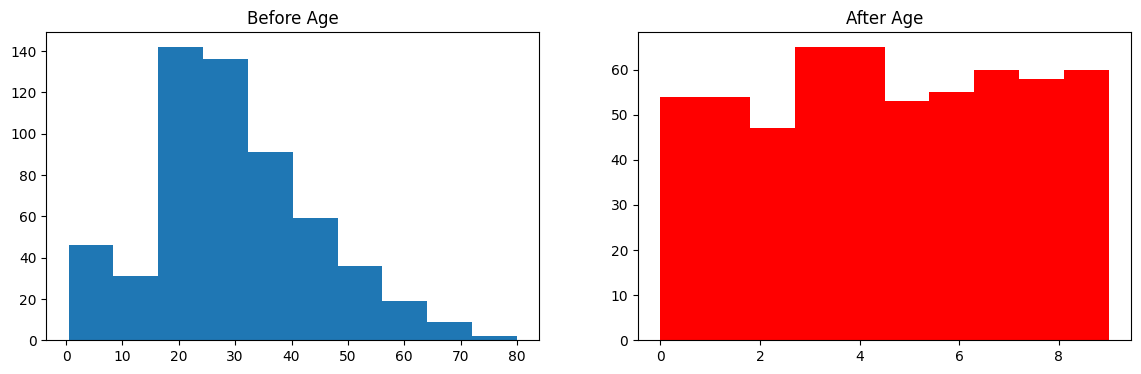

In [120]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X_train["Age"])
plt.title("Before Age")

plt.subplot(122)
plt.hist(X_train_trf[:,0],color='red')
plt.title("After Age")
plt.show()





In [123]:
def descritization_number(nbin,strategy):

  bins_age_fare=KBinsDiscretizer(n_bins=nbin, encode="ordinal", strategy=strategy)
  column_trasfer=ColumnTransformer([("trf1", bins_age,["Age","Fare"])], remainder="passthrough")

  X_trf=column_trasfer.fit_transform(X)
  dt=DecisionTreeClassifier()
  print(np.mean(cross_val_score(dt,X_trf,y,cv=10,scoring='accuracy')))

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(X["Age"])
  plt.title("Before Age")

  plt.subplot(122)
  plt.hist(X_trf[:,0],color='red')
  plt.title("After Age")
  plt.show()


0.682140062597809


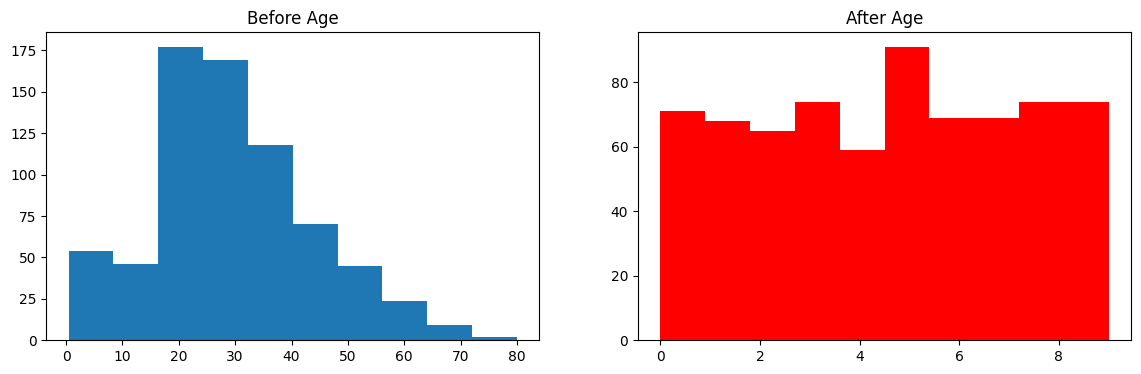

In [124]:
descritization_number(10,"quantile")

0.682140062597809


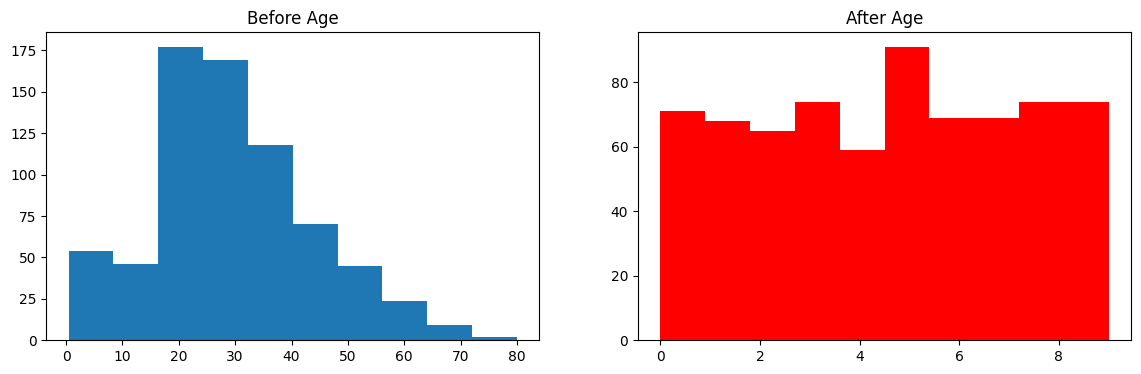

In [125]:
descritization_number(15,"uniform")

0.682140062597809


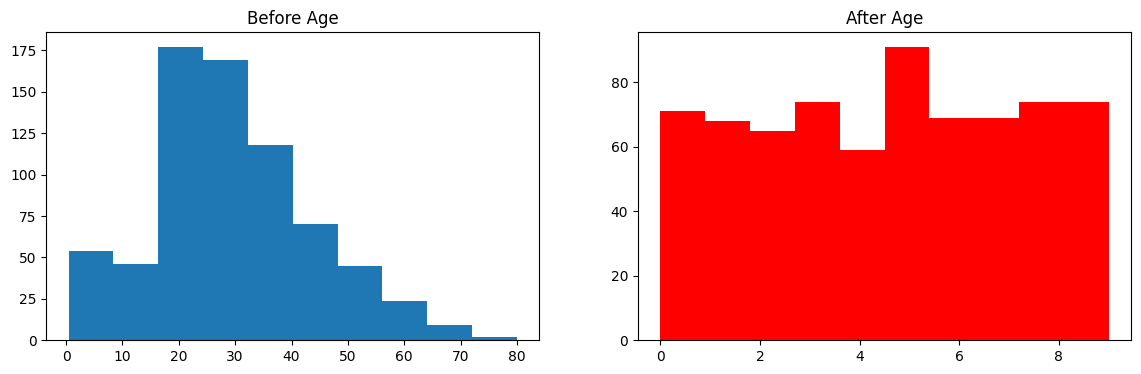

In [126]:
descritization_number(15,"kmeans")